##### imports

# TO-DO:
- ~Attempt 33/33/33 split based on *prompt*~
    - ~try same prompt~
    - ~try different prompts(?)~
- ~visualize results~
    - ~confusion matrix?~
- ~compare to previous iterations~


In [ ]:
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.applications import MobileNetV2
from keras import layers
from tensorflow import data as tf_data
import os
import random
import zipfile
import shutil
import pandas as pd
from sklearn.metrics import (roc_curve, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay,classification_report)

import reload_data2 as reloadata

#### Load Data

In [3]:
try:
    shutil.rmtree("/content/Handwriting_Images")
except:
    pass

!unzip /content/Handwriting_Images_90sorted.zip

Archive:  /content/Handwriting_Images_90sorted.zip
   creating: Handwriting_Images/
  inflating: __MACOSX/._Handwriting_Images  
   creating: Handwriting_Images/w0129/
   creating: Handwriting_Images/w0142/
   creating: Handwriting_Images/w0145/
   creating: Handwriting_Images/w0128/
   creating: Handwriting_Images/w0126/
   creating: Handwriting_Images/w0121/
   creating: Handwriting_Images/w0144/
   creating: Handwriting_Images/w0143/
   creating: Handwriting_Images/w0031/
   creating: Handwriting_Images/w0009/
   creating: Handwriting_Images/w0036/
   creating: Handwriting_Images/w0038/
  inflating: Handwriting_Images/.DS_Store  
  inflating: __MACOSX/Handwriting_Images/._.DS_Store  
   creating: Handwriting_Images/w0062/
   creating: Handwriting_Images/w0091/
   creating: Handwriting_Images/w0006/
   creating: Handwriting_Images/w0001/
   creating: Handwriting_Images/w0030/
   creating: Handwriting_Images/w0064/
   creating: Handwriting_Images/w0063/
   creating: Handwriting_Images

In [4]:
shutil.rmtree("/content/__MACOSX")

#### Sort by prompt

In [5]:
prompt_ids = ["LND","WOZ","PHR"]

In [6]:
w_ids=reloadata.w_ids
type(w_ids)

list

In [7]:
#path to data
data_folder_path = "/content/Handwriting_Images"

In [8]:
 #create folders for prompts & subfolders for writers under prompts
for writer in w_ids:
    for prompt in prompt_ids:
        os.makedirs(f"{data_folder_path}/{prompt}/{writer}",exist_ok=True)

In [9]:
#sort images according to prompt into writer subfolders
for writer in w_ids:
    #iterate over every writer folder
    writer_path = f"{data_folder_path}/{writer}"
    #print(writer)
    #print(writer_path)

    #list of every image sample for writer
    samples = os.listdir(writer_path)

    #iterate over every image and move to writer subfolder under prompt folder
    for image in samples:
        image_path = f"{writer_path}/{image}" #path to specific image
        for prompt in prompt_ids: #check every prompt
            if prompt in image:
                #move image to proper prompt folder under proper writer subfolder
                dest_path = f"{data_folder_path}/{prompt}/{writer}/{image}"
                shutil.move(image_path, dest_path)
                #print(f"MOVED: {image} to {prompt}")
                break
            else:
                continue
            #image isnt being classified at all
            print(f"ERROR: prompt not identified:\n{image}")

    shutil.rmtree(writer_path)

# Modelling

In [10]:
IMAGE_SIZE = (384,384)
BATCH_SIZE = 64
INPUT_SHAPE = IMAGE_SIZE + (3,)
NUM_CLASSES = 90

In [17]:
base_model = MobileNetV2(include_top = False,
                        classifier_activation="softmax",
                        weights = "imagenet",
                        input_shape=(IMAGE_SIZE + (3,))
                        )

def alt_make_transfer_model(input_shape, num_classes, modname):
    backbone = base_model
    backbone.trainable = False

    inputs = layers.Input(input_shape)
    x = keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = backbone(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(num_classes, activation=None)(x)

    return keras.Model(inputs, outputs, name=modname)

model = alt_make_transfer_model(input_shape=INPUT_SHAPE, num_classes=90,
                                modname="prompt_split")

backbone = model.get_layer("mobilenetv2_1.00_224")
backbone.trainable = True
for layer in backbone.layers[:-5]:
    layer.trainable = False

/tmp/ipython-input-5908447.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(include_top = False,


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


##### Train/Val/Test Split

    NOT randomizing prompts

In [ ]:
prompt_ids

['LND', 'WOZ', 'PHR']

In [ ]:
#shuffle/randomize which prompt gets globally chosen
random.shuffle(prompt_ids)

train_ds = tf.keras.utils.image_dataset_from_directory(
        f"{data_folder_path}/{prompt_ids[0]}",
        labels='inferred',
        color_mode='rgb',
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        )
val_ds = tf.keras.utils.image_dataset_from_directory(
        f"{data_folder_path}/{prompt_ids[1]}",
        labels='inferred',
        color_mode='rgb',
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        )
test_ds = tf.keras.utils.image_dataset_from_directory(
        f"{data_folder_path}/{prompt_ids[2]}",
        labels='inferred',
        color_mode='rgb',
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        )

train_ds = train_ds.prefetch(tf_data.AUTOTUNE)
val_ds = val_ds.prefetch(tf_data.AUTOTUNE)
test_ds = test_ds.prefetch(tf_data.AUTOTUNE)

Found 810 files belonging to 90 classes.
Found 810 files belonging to 90 classes.
Found 810 files belonging to 90 classes.


### MobileNet

In [ ]:
%%time

epochs = 100

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc"),
             keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_acc")],
    )

history = model.fit(
    train_ds,
    epochs= epochs,
    validation_data= val_ds)

model.save("/content/MobileNet_promptthirds.keras")

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - acc: 0.0183 - loss: 4.6755 - top3_acc: 0.0384 - val_acc: 0.0123 - val_loss: 4.9588 - val_top3_acc: 0.0432
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 400ms/step - acc: 0.0298 - loss: 4.6062 - top3_acc: 0.0594 - val_acc: 0.0123 - val_loss: 4.9541 - val_top3_acc: 0.0407
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 394ms/step - acc: 0.0172 - loss: 4.5832 - top3_acc: 0.0449 - val_acc: 0.0111 - val_loss: 4.9464 - val_top3_acc: 0.0420
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 408ms/step - acc: 0.0104 - loss: 4.5350 - top3_acc: 0.0534 - val_acc: 0.0111 - val_loss: 4.9377 - val_top3_acc: 0.0420
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 393ms/step - acc: 0.0327 - loss: 4.4460 - top3_acc: 0.0791 - val_acc: 0.0123 - val_loss: 4.9232 - val_top3_acc: 0.0420
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 401ms/step - acc: 0.0348 - loss: 4.4166 - top3_acc: 0.0897 - val_acc: 0.0123 - val_loss: 4.9086 - val_top3_acc: 0.0420
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━

    pure accuracy is a harsh metric
    top5 accuracy reaches ~97%
    top3 accuracy ~80%

In [ ]:
lossacc = pd.DataFrame(history.history)
lossacc.to_csv("MBNV2_promptthirds_lossacc.csv")

### Visualization

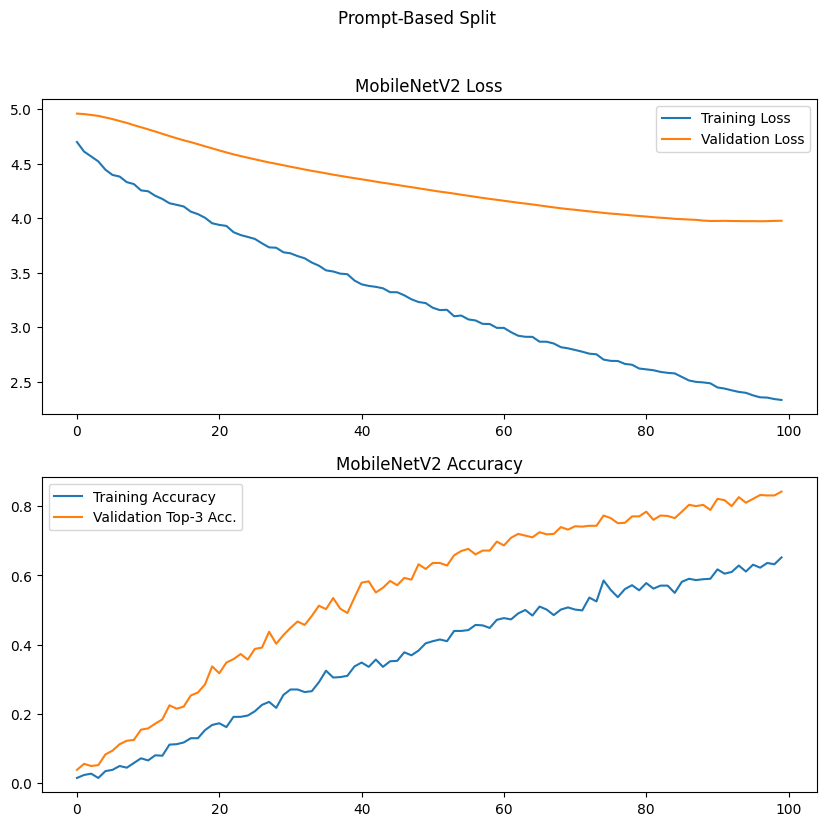

In [ ]:
#plot loss and accuracy curves
plt.figure(figsize=(10,9))
plt.suptitle("Prompt-Based Split")
plt.subplot(2,1,1)
plt.plot(range(len(history.history["loss"])),history.history["loss"],label="Training Loss")
plt.plot(range(len(history.history["val_loss"])),history.history["val_loss"],label="Validation Loss")
plt.title("MobileNetV2 Loss")
plt.legend()

plt.subplot(2,1,2)
plt.plot(range(len(history.history["acc"])),history.history["acc"],label="Training Accuracy")
plt.plot(range(len(history.history["top3_acc"])),history.history["top3_acc"],label="Validation Top-3 Acc.")
plt.title("MobileNetV2 Accuracy")
plt.legend()

plt.show()

#### Test set

In [ ]:
#test_loss, test_acc = model.evaluate(test_ds)
#print(f"Test accuracy: {test_acc:.3f}")
#print(f"Test loss: {test_loss:.3f}")

results = model.evaluate(test_ds, return_dict=True)

print(results)

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 202ms/step - acc: 0.0683 - loss: 4.2194 - top3_acc: 0.1334
{'acc': 0.06172839552164078, 'loss': 4.210299015045166, 'top3_acc': 0.12839506566524506}


    20% top5 accuracy suggests major overfitting

2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step


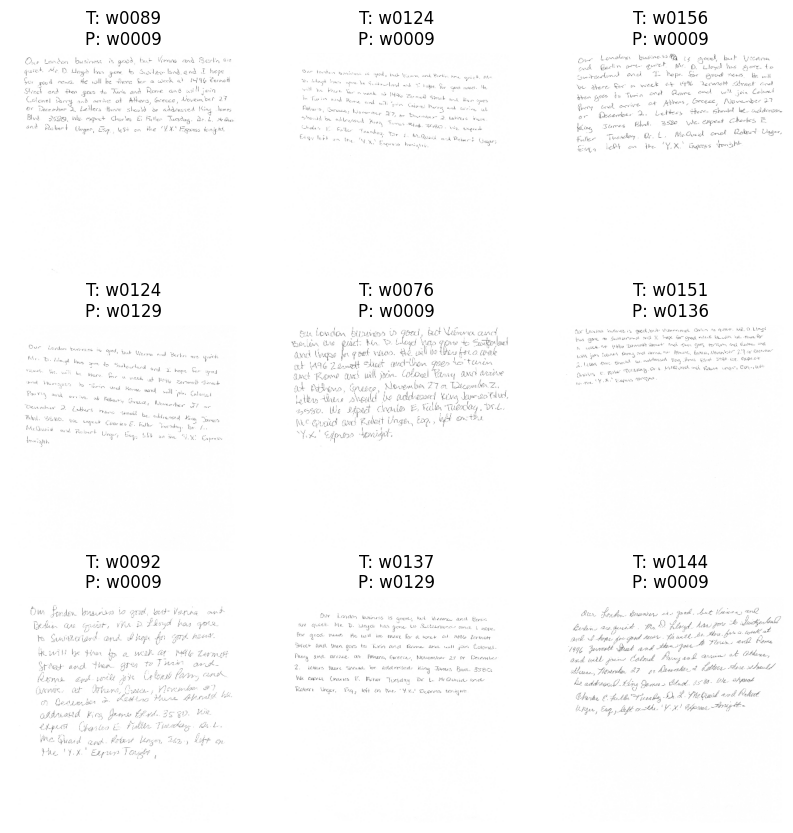

In [ ]:
for images, labels in test_ds.take(1):
    preds = model.predict(images)
    pred_labels = np.argmax(preds, axis=1)

    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        true_label = w_ids[labels[i]]
        pred_label = w_ids[pred_labels[i]]
        plt.title(f"T: {true_label}\nP: {pred_label}")
        plt.axis("off")
    plt.show()

In [ ]:
#Get predictions
y_pred_logits = model.predict(test_ds)
y_pred = np.argmax(y_pred_logits, axis=1)

y_true = np.concatenate([
    y.numpy() for _, y in test_ds
])

13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 665ms/step


In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=w_ids,
    digits=4
))

              precision    recall  f1-score   support

       w0001     0.0000    0.0000    0.0000         9
       w0002     0.0000    0.0000    0.0000         9
       w0003     0.0435    0.1111    0.0625         9
       w0004     0.0000    0.0000    0.0000         9
       w0005     0.0000    0.0000    0.0000         9
       w0006     0.0000    0.0000    0.0000         9
       w0009     0.0110    0.6667    0.0216         9
       w0010     0.0000    0.0000    0.0000         9
       w0011     0.0000    0.0000    0.0000         9
       w0012     0.0000    0.0000    0.0000         9
       w0013     0.0000    0.0000    0.0000         9
       w0015     0.0000    0.0000    0.0000         9
       w0016     0.0000    0.0000    0.0000         9
       w0017     0.0000    0.0000    0.0000         9
       w0018     0.0000    0.0000    0.0000         9
       w0020     0.0000    0.0000    0.0000         9
       w0022     0.0000    0.0000    0.0000         9
       w0023     0.0000    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


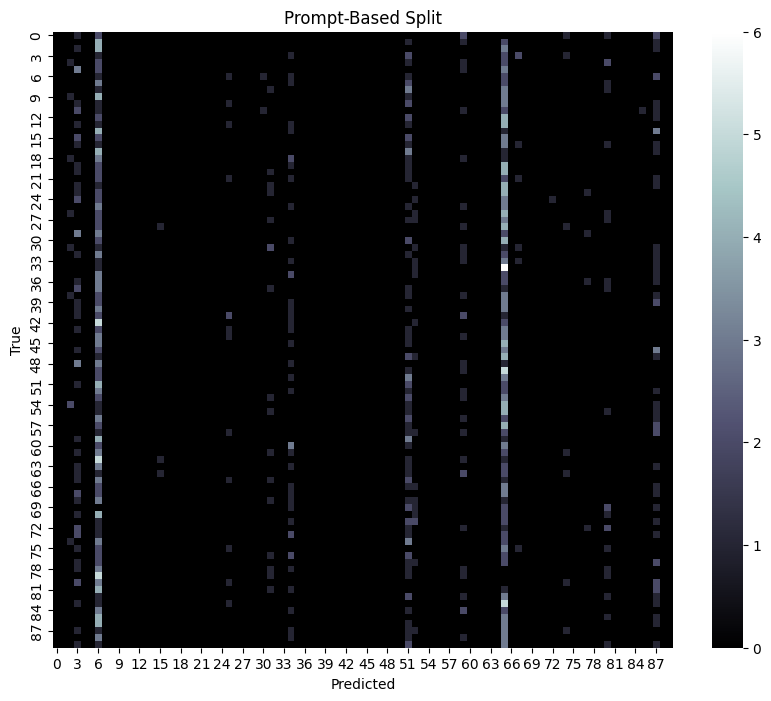

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.title("Prompt-Based Split")
sns.heatmap(cm, annot=False, cmap="bone")
plt.xlabel("Predicted")
plt.ylabel("True")
#plt.title("Confusion Matrix")
plt.show()

    Over predicting only a few classes?? Why?

    Issue specific to MobileNet?

##Trying the same thing with unfreezing backbone (skipped)

In [ ]:
model.summary() #first model

Model: "prompt_split"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 12, 12, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 90)             │       115,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,043,856 (15.43 MB)

 Trainable params: 835,290 (3.19 MB)

 Non-trainable params: 1,537,984 (5.87 MB)

 Optimizer params: 1,670,582 (6.37 MB)

In [ ]:
#backbone = model.get_layer("efficientnetb1")

#backbone.trainable = True

#for layer in backbone.layers[:-5]:
#    layer.trainable = False

#model.compile(
#    optimizer=keras.optimizers.Adam(learning_rate=1e-5), # <-- decreased
#    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
#    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc"),
#             keras.metrics.SparseTopKCategoricalAccuracy(k=3)],
#    )

In [ ]:
#model.summary() #unfrozen model

Model: "prompt_split"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb1 (Functional)     │ (None, 8, 8, 1280)     │     6,575,239 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 90)             │       115,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,690,529 (25.52 MB)

 Trainable params: 2,587,098 (9.87 MB)

 Non-trainable params: 4,103,431 (15.65 MB)

In [ ]:
%%time

epochs = 100

#model.compile(
#    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
#    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
#    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc")],
#    )

history = model.fit(
    train_ds,
    epochs= epochs,
    validation_data= val_ds)

model.save("/content/EfficientNet_promptthirds_unfrozen.keras")

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 88s 4s/step - acc: 0.3829 - loss: 2.5248 - val_acc: 0.0185 - val_loss: 8.6451
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 384ms/step - acc: 0.4066 - loss: 2.2949 - val_acc: 0.0185 - val_loss: 8.4461
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 385ms/step - acc: 0.4572 - loss: 2.1470 - val_acc: 0.0198 - val_loss: 8.2337
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 397ms/step - acc: 0.4833 - loss: 2.1001 - val_acc: 0.0198 - val_loss: 8.0374
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 385ms/step - acc: 0.4933 - loss: 1.9246 - val_acc: 0.0198 - val_loss: 7.8589
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 398ms/step - acc: 0.5274 - loss: 1.8808 - val_acc: 0.0198 - val_loss: 7.7143
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 385ms/step - acc: 0.5272 - loss: 1.8009 - val_acc: 0.0198 - val_loss: 7.5664
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 384ms/step - acc: 0.5925 - loss: 1.7271 - val_acc: 0.0198 - val_loss: 7.4435
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 400ms/st

In [ ]:
lossacc = pd.DataFrame(history.history)
lossacc.to_csv("promptthirds_unfrozen_lossacc.csv")

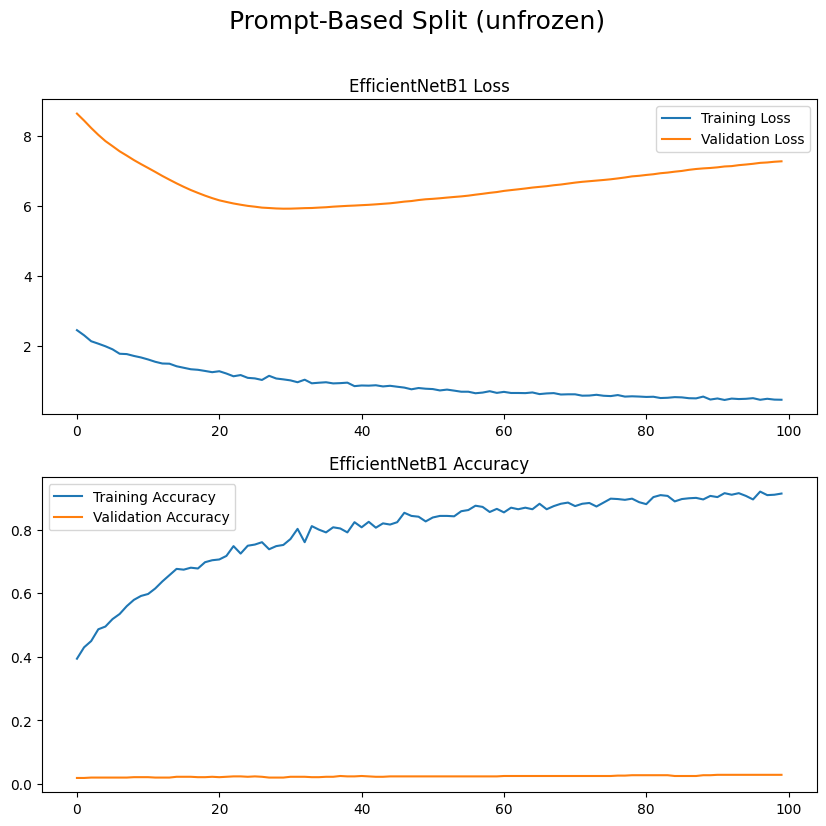

In [ ]:
#plot loss and accuracy curves
plt.figure(figsize=(10,9))
plt.suptitle("Prompt-Based Split (unfrozen)",size=18)
plt.subplot(2,1,1)
plt.plot(range(len(history.history["loss"])),history.history["loss"],label="Training Loss")
plt.plot(range(len(history.history["val_loss"])),history.history["val_loss"],label="Validation Loss")
plt.title("EfficientNetB1 Loss")
plt.legend()

plt.subplot(2,1,2)
plt.plot(range(len(history.history["acc"])),history.history["acc"],label="Training Accuracy")
plt.plot(range(len(history.history["val_acc"])),history.history["val_acc"],label="Validation Accuracy")
plt.title("EfficientNetB1 Accuracy")
plt.legend()

plt.show()

    overfitting again

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.3f}")
print(f"Test loss: {test_loss:.3f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 200ms/step - acc: 0.5981 - loss: 1.3487
Test accuracy: 0.605
Test loss: 1.321


In [ ]:
#Get predictions
y_pred_logits = model.predict(test_ds)
y_pred = np.argmax(y_pred_logits, axis=1)

y_true = np.concatenate([
    y.numpy() for _, y in test_ds
])

13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 893ms/step


In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=w_ids,
    digits=4
))

              precision    recall  f1-score   support

       w0001     0.0000    0.0000    0.0000         9
       w0002     0.0000    0.0000    0.0000         9
       w0003     0.0000    0.0000    0.0000         9
       w0004     0.0000    0.0000    0.0000         9
       w0005     0.0000    0.0000    0.0000         9
       w0006     0.1000    0.1111    0.1053         9
       w0009     0.0000    0.0000    0.0000         9
       w0010     0.0000    0.0000    0.0000         9
       w0011     0.0000    0.0000    0.0000         9
       w0012     0.0000    0.0000    0.0000         9
       w0013     0.0000    0.0000    0.0000         9
       w0015     0.0000    0.0000    0.0000         9
       w0016     0.0000    0.0000    0.0000         9
       w0017     0.0000    0.0000    0.0000         9
       w0018     0.0000    0.0000    0.0000         9
       w0020     0.0833    0.1111    0.0952         9
       w0022     0.0000    0.0000    0.0000         9
       w0023     0.0000    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


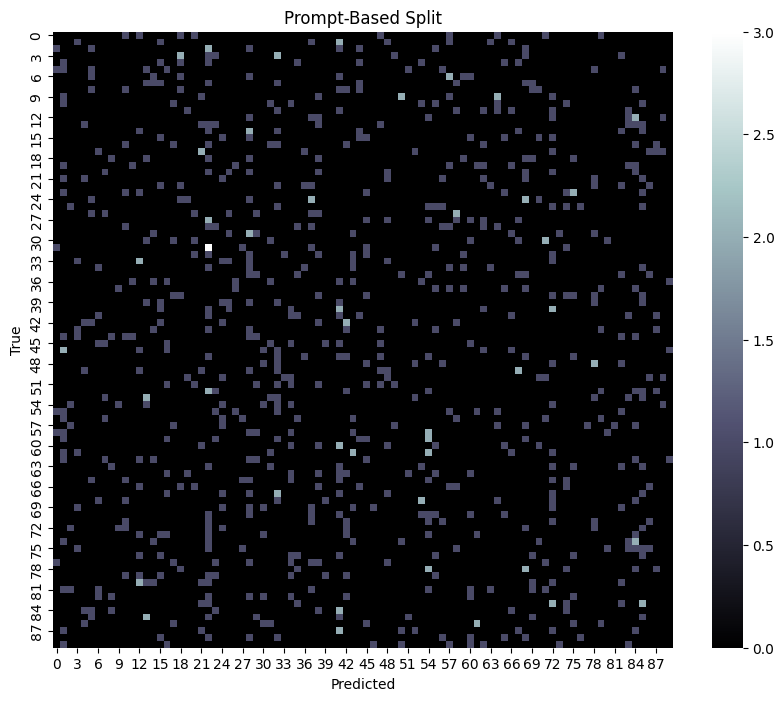

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.title("Prompt-Based Split (unfrozen)")
sns.heatmap(cm, annot=False, cmap="bone")
plt.xlabel("Predicted")
plt.ylabel("True")
#plt.title("Confusion Matrix")
plt.show()

# Randomized prompts

In [11]:
#recreate writer folders
for writer in w_ids:
    os.mkdir(f"{data_folder_path}/{writer}")

In [12]:
for prompt in prompt_ids:
    for writer in w_ids:
        shutil.move(f"{data_folder_path}/{prompt}/{writer}",f"{data_folder_path}/{writer}/{prompt}")

In [13]:
os.mkdir(f"{data_folder_path}/train")
os.mkdir(f"{data_folder_path}/val")
os.mkdir(f"{data_folder_path}/test")

In [14]:
for writer in w_ids:
    ind=random.randint(0,2)

    train_subfolder = f"{data_folder_path}/{writer}/{prompt_ids[ind]}"
    #os.makedirs(train_subfolder,exist_ok=True)
    shutil.move(train_subfolder,f"{data_folder_path}/train/{writer}")

    val_subfolder = f"{data_folder_path}/{writer}/{prompt_ids[(ind+1)%3]}"
    #os.makedirs(val_subfolder,exist_ok=True)
    shutil.move(val_subfolder,f"{data_folder_path}/val/{writer}")

    test_subfolder = f"{data_folder_path}/{writer}/{prompt_ids[(ind+2)%3]}"
    #os.makedirs(test_subfolder,exist_ok=True)
    shutil.move(test_subfolder,f"{data_folder_path}/test/{writer}")

### train/test/val

In [15]:
#shuffle/randomize which prompt gets globally chosen
random.shuffle(prompt_ids)

train_ds = tf.keras.utils.image_dataset_from_directory(
        f"{data_folder_path}/train",
        labels='inferred',
        color_mode='rgb',
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        )
val_ds = tf.keras.utils.image_dataset_from_directory(
        f"{data_folder_path}/val",
        labels='inferred',
        color_mode='rgb',
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        )
test_ds = tf.keras.utils.image_dataset_from_directory(
        f"{data_folder_path}/test",
        labels='inferred',
        color_mode='rgb',
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        )

train_ds = train_ds.prefetch(tf_data.AUTOTUNE)
val_ds = val_ds.prefetch(tf_data.AUTOTUNE)
test_ds = test_ds.prefetch(tf_data.AUTOTUNE)

Found 810 files belonging to 90 classes.
Found 810 files belonging to 90 classes.
Found 810 files belonging to 90 classes.


### Modelling

In [18]:
model=alt_make_transfer_model(INPUT_SHAPE,90,"MBNV2_promptthirds_random")

backbone = model.get_layer("mobilenetv2_1.00_224")

backbone.trainable = True

for layer in backbone.layers[:-5]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc"),
             keras.metrics.SparseTopKCategoricalAccuracy(k=3,name="top3_acc")],
    )

model.summary()

Model: "MBNV2_promptthirds_random"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 12, 12, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 90)             │       115,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,373,274 (9.05 MB)

 Trainable params: 835,290 (3.19 MB)

 Non-trainable params: 1,537,984 (5.87 MB)

In [19]:
%%time

epochs = 100

history = model.fit(
    train_ds,
    epochs= epochs,
    validation_data= val_ds)

model.save("/content/MBNV2_promptthirds_random.keras")

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 90s 4s/step - acc: 0.0078 - loss: 4.6943 - top3_acc: 0.0298 - val_acc: 0.0086 - val_loss: 4.8970 - val_top3_acc: 0.0321
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 415ms/step - acc: 0.0127 - loss: 4.5794 - top3_acc: 0.0429 - val_acc: 0.0086 - val_loss: 4.8869 - val_top3_acc: 0.0321
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 402ms/step - acc: 0.0189 - loss: 4.4853 - top3_acc: 0.0515 - val_acc: 0.0086 - val_loss: 4.8812 - val_top3_acc: 0.0333
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 404ms/step - acc: 0.0308 - loss: 4.3937 - top3_acc: 0.0989 - val_acc: 0.0086 - val_loss: 4.8753 - val_top3_acc: 0.0358
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 411ms/step - acc: 0.0301 - loss: 4.3234 - top3_acc: 0.0955 - val_acc: 0.0086 - val_loss: 4.8688 - val_top3_acc: 0.0358
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 401ms/step - acc: 0.0442 - loss: 4.2888 - top3_acc: 0.0968 - val_acc: 0.0086 - val_loss: 4.8623 - val_top3_acc: 0.0395
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━

In [20]:
lossacc = pd.DataFrame(history.history)
lossacc.to_csv("promptthirds_random_lossacc.csv")

#### Visualization/Evalution

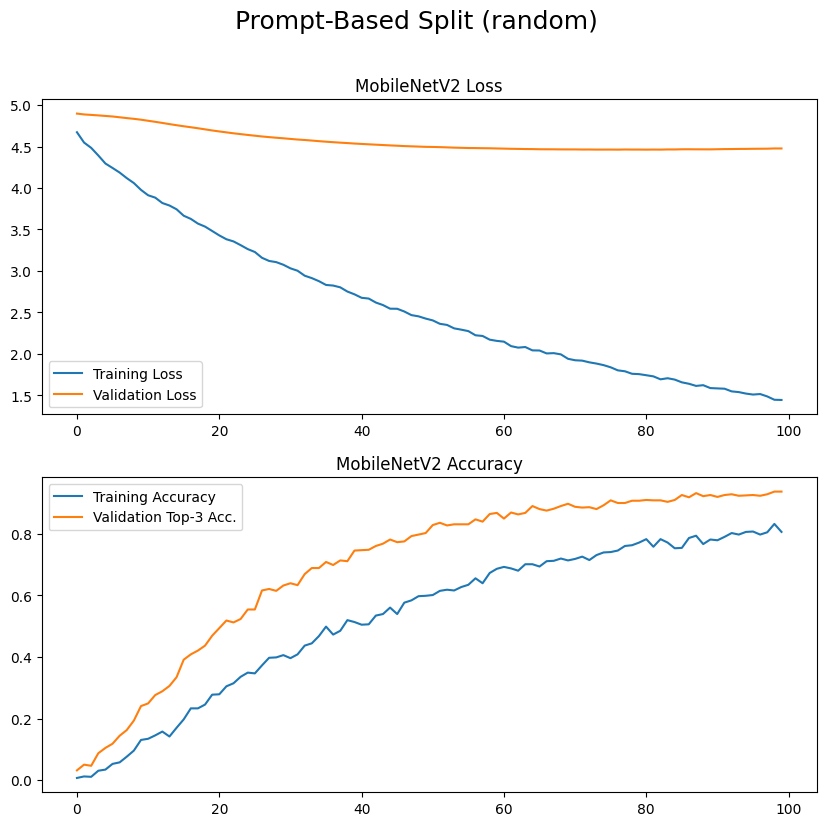

In [21]:
#plot loss and accuracy curves
plt.figure(figsize=(10,9))
plt.suptitle("Prompt-Based Split (random)",size=18)
plt.subplot(2,1,1)
plt.plot(range(len(history.history["loss"])),history.history["loss"],label="Training Loss")
plt.plot(range(len(history.history["val_loss"])),history.history["val_loss"],label="Validation Loss")
plt.title("MobileNetV2 Loss")
plt.legend()

plt.subplot(2,1,2)
plt.plot(range(len(history.history["acc"])),history.history["acc"],label="Training Accuracy")
plt.plot(range(len(history.history["top3_acc"])),history.history["top3_acc"],label="Validation Top-3 Acc.")
plt.title("MobileNetV2 Accuracy")
plt.legend()

plt.show()

In [22]:
#test_loss, test_acc = model.evaluate(test_ds)
#print(f"Test accuracy: {test_acc:.3f}")
#print(f"Test loss: {test_loss:.3f}")

results = model.evaluate(test_ds, return_dict=True)

print(results)

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 193ms/step - acc: 0.1046 - loss: 4.2990 - top3_acc: 0.2480
{'acc': 0.101234570145607, 'loss': 4.3102569580078125, 'top3_acc': 0.2419753074645996}


In [23]:
#Get predictions
y_pred_logits = model.predict(test_ds)
y_pred = np.argmax(y_pred_logits, axis=1)

y_true = np.concatenate([
    y.numpy() for _, y in test_ds
])

13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 665ms/step


In [24]:
print(classification_report(
    y_true,
    y_pred,
    target_names=w_ids,
    digits=4
))

              precision    recall  f1-score   support

       w0001     0.0000    0.0000    0.0000         9
       w0002     0.0000    0.0000    0.0000         9
       w0003     0.0204    0.1111    0.0345         9
       w0004     0.0000    0.0000    0.0000         9
       w0005     0.0000    0.0000    0.0000         9
       w0006     0.0000    0.0000    0.0000         9
       w0009     0.0000    0.0000    0.0000         9
       w0010     0.0588    0.1111    0.0769         9
       w0011     0.0000    0.0000    0.0000         9
       w0012     0.0000    0.0000    0.0000         9
       w0013     0.0000    0.0000    0.0000         9
       w0015     0.0000    0.0000    0.0000         9
       w0016     0.0000    0.0000    0.0000         9
       w0017     0.0000    0.0000    0.0000         9
       w0018     0.0000    0.0000    0.0000         9
       w0020     0.0000    0.0000    0.0000         9
       w0022     0.0000    0.0000    0.0000         9
       w0023     0.0000    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


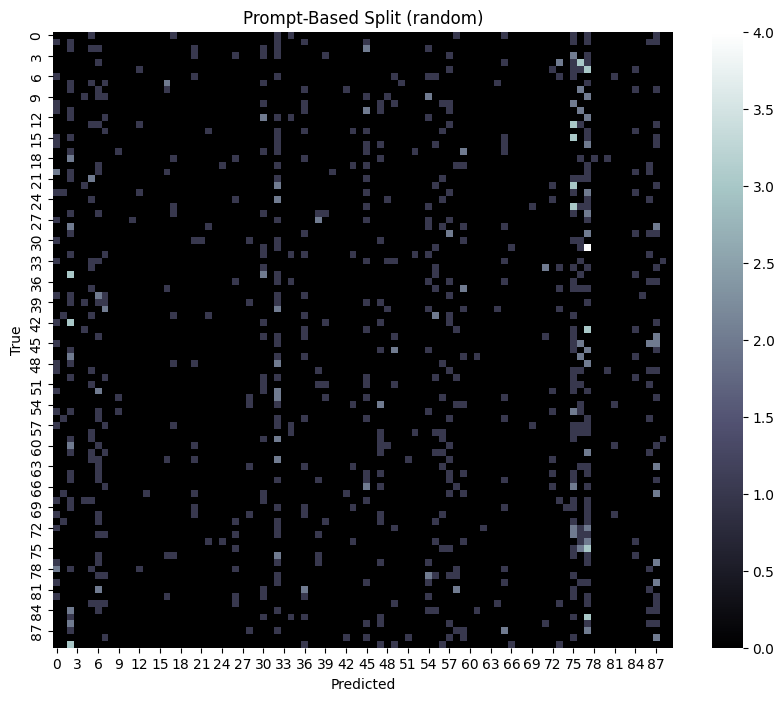

In [25]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.title("Prompt-Based Split (random)")
sns.heatmap(cm, annot=False, cmap="bone")
plt.xlabel("Predicted")
plt.ylabel("True")
#plt.title("Confusion Matrix")
plt.show()

# NEXT:
* Do "normal" run and calculate confusion matrix & classification report
* Try augmentations